# Download MNIST dataset

In [ ]:
from src.QDDPM_torch_angel import DiffusionModel, QDDPM, WassDistance
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader
from pathlib import Path
from tqdm import tqdm
import numpy as np
import torch
import time

import matplotlib.pyplot as plt
from matplotlib import rc
rc('text', usetex=True)
rc('axes', linewidth=3)

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# This label will identificate the files generated in this notebook. E.g. if you work only with 0 and 1 digits, use '01'.
customlabel = '01' 
T = 2 # Nr of time steps

# THIS TRANSFORMATION WILL DETERMINE THE NR OF QUBITS NEEDED (at least 2^n_pixels):
transform = transforms.Compose([transforms.Resize(2), transforms.ToTensor()])
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

Please first ``pip install -U qiskit`` to enable related functionality in translation module
Please first ``pip install -U cirq`` to enable related functionality in translation module


CUDA available: False
CUDA device: None


Sample shape: torch.Size([1, 2, 2]), Label: 5
Number of pixels in the image: 4
Number of qubits needed: 2


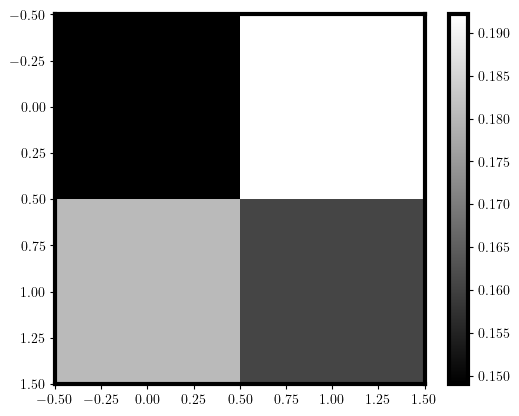

In [2]:
# Plot just the first sample

import matplotlib.pyplot as plt

sample, label = mnist[0]
plt.imshow(sample.squeeze(), cmap='gray')
plt.colorbar()

print(f"Sample shape: {sample.shape}, Label: {label}")
print(f"Number of pixels in the image: {sample.numel()}")
print(f"Number of qubits needed: {int(np.ceil(np.log2(sample.numel())))}")

# Generate dataset

In [3]:
# Save our embedded mnist data in quantum states

# Get digits 0 and 1 from MNIST dataset.
indices = [i for i in range(len(mnist)) if mnist.targets[i] in [0, 1]]
mnist_01 = Subset(mnist, indices)
batch_size = len(mnist_01)
dataloader = DataLoader(mnist_01, batch_size=batch_size, shuffle=False)

dataset, labels = next(iter(dataloader)) # Digit images 0, 1; labels

dataset = dataset[:2] # OPTIONAL Reduce dataset size

# Process all samples at once
dataset = dataset.reshape(dataset.shape[0], -1) # Reshape each sample to a 1D vector (flatten the image)
dataset = np.array(dataset, dtype=np.complex64) # Convert to complex type for quantum state representation
print(dataset.shape) # Should be (number_of_samples, number_of_pixels)

dataset = dataset / np.linalg.norm(dataset, axis=1, keepdims=True) # Normalize each sample to ensure it represents a valid quantum state

# Save the dataset 

# N = length of the dataset
# M = number of features (pixels) in each sample
N = dataset.shape[0]
M = dataset.shape[1]
savedir = Path("data/MNIST/qdatasets")
savedir.mkdir(parents=True, exist_ok=True)

filename = savedir / f"qstates_{customlabel}_N{len(dataset)}_M{M}.npy"
np.save(filename, dataset)


(2, 4)


# Generate the diffused states

In [4]:
# Load the dataset
savedir = Path("data/MNIST/qdatasets")
filename = f"qstates_{customlabel}_N{len(dataset)}_M{M}.npy"
dataset = np.load(savedir / filename) 
dataset = torch.from_numpy(dataset).to(device)
# dataset = dataset[:500] # Testing

# How many qubits do we need?
n_pixels = dataset[0].reshape(-1).shape[0]
n_qubits = int(np.ceil(np.log2(n_pixels)))
print(f"Number of samples in the dataset: {len(dataset)}")
print(f"Number of pixels in each sample: {n_pixels}")
print(f"Number of qubits needed to encode the data: {n_qubits}")

# Diffusion
# T = T # number of diffusion steps
n = n_qubits
M = n_pixels
Ndata = dataset.shape[0]

diff_hs = np.linspace(1., 4., T)
diff_hs = torch.from_numpy(diff_hs).to(device)

model_diff = DiffusionModel(n, T, Ndata)
states_0 = dataset
states = np.zeros((T+1, Ndata, 2**n), dtype=np.complex64)
states[0] = states_0.numpy()
for t in tqdm(range(1, T+1)):
    states[t] = model_diff.set_diffusionData_t(t, states_0, diff_hs[:t], seed=t).numpy()

savedir = Path("data/MNIST/qdatasets")
savedir.mkdir(parents=True, exist_ok=True)
filename = f"qstatesdiffused_{customlabel}_N{len(dataset)}_M{M}_T{T}.npy"
np.save(savedir / filename, states)

Number of samples in the dataset: 2
Number of pixels in each sample: 4
Number of qubits needed to encode the data: 2


100%|██████████| 2/2 [00:00<00:00, 62.15it/s]


Visualize the decay of fidelity

In [5]:
import matplotlib.pyplot as plt
from src.QDDPM_torch_angel import WassDistance

# visualize the fidelity decay in the diffusion process
# T = T
# N = N
# M = M

filename = f"data/MNIST/qdatasets/qstatesdiffused_{customlabel}_N{N}_M{M}_T{T}.npy"
dataset_diff = np.load(filename)
print(dataset_diff.shape)

states_0 = torch.from_numpy(dataset_diff[0]) # [N, 2^n]
dataset_diff = torch.from_numpy(dataset_diff) # [T, N, 2^n]
print(states_0.shape)

n_pixels = dataset[0].reshape(-1).shape[0]
n_qubits = int(np.ceil(np.log2(n_pixels)))
n = n_qubits

wass = np.zeros(T+1)
for t in tqdm(range(T+1)):
    np.random.seed()
    idx = np.random.choice(N, N, replace=False)
    wass[t] = WassDistance(states_0, dataset_diff[t,idx])

savedir = Path("data/MNIST/qdatasets")
savedir.mkdir(parents=True, exist_ok=True) 
filename = f"wass_{customlabel}_N{N}_M{M}_T{T}.npy" 
np.save(savedir / filename, wass)

(3, 2, 4)
torch.Size([2, 4])


100%|██████████| 3/3 [00:00<00:00, 144.40it/s]


(3,)


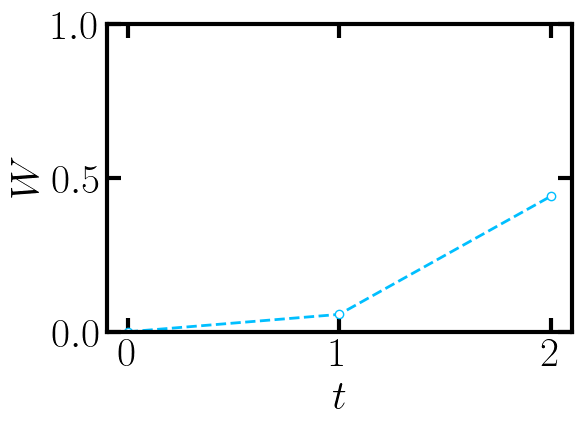

In [6]:
savedir = Path("data/MNIST/qdatasets")
filename = f"wass_{customlabel}_N{N}_M{M}_T{T}.npy" 
wass = np.load(savedir / filename)
print(wass.shape)

fig, ax = plt.subplots(figsize=(6, 4))
indices = np.random.permutation(N)
# for i in range(10):
#     ax.plot(range(T+1), 1,
#             '--', lw=1, c='grey')
# ax.plot(range(T+1), wass, 'o--', markersize=8, lw=2, c='r')
ax.plot(wass, 'o--', mfc='white', markersize=6, lw=2, c='deepskyblue', 
        label=r'$W(\mathcal{S}_t,\mathcal{S}^\prime_0)$')
ax.set_ylabel(r'$W$', fontsize=30)
ax.set_xlabel(r'$t$', fontsize=30)
ax.set_ylim(0,1)
# ax.set_yscale('log')
ax.tick_params(direction='in', length=10, width=3, top='on', right='on', labelsize=30)

# Training. Load the dataset

In [7]:
# Load the dataset.
savedir = Path("data/MNIST/qdatasets")
filename = f"qstatesdiffused_{customlabel}_N{N}_M{M}_T{T}.npy" 
dataset = np.load(savedir / filename) 
# dataset = torch.from_numpy(dataset).to(device) # NOT YET
print(dataset.shape) # Should be (number_of_samples, number_of_pixels)

# How many qubits do we need?
n_pixels = dataset[0,0].reshape(-1).shape[0]
n_qubits = int(np.ceil(np.log2(n_pixels))) # Get the number of qubits needed to encode the data
print(f"Number of pixels in each sample: {n_pixels}")
print(f"Number of qubits needed to encode the data: {n_qubits}")

(3, 2, 4)
Number of pixels in each sample: 4
Number of qubits needed to encode the data: 2


# Amplitude embedding and training

In [8]:
def Training_t(model, t, inputs_T, params_tot, Ndata, epochs):
    '''
    the trianing for the backward PQC at step t
    input_tplus1: the output from step t+1, as the role of input at step t
    Args:
    model: the QDDPM model
    t: the diffusion step
    inputs_T: the input data at step t=T
    params_tot: collection of PQC parameters before step t
    Ndata: number of samples in dataset
    epochs: the number of iterations
    '''
    input_tplus1 = model.prepareInput_t(inputs_T, params_tot, t, Ndata) # prepare input
    states_diff = model.states_diff
    loss_hist = [] # record of training history

    # initialize parameters
    np.random.seed()
    params_t = torch.tensor(np.random.normal(size=2 * model.n_tot * model.L), requires_grad=True)
    # set optimizer and learning rate decay
    optimizer = torch.optim.Adam([params_t], lr=0.0005)
    
    t0 = time.time()
    for epoch in range(epochs):
        # Create a random batch of NDdata samples, for each epoch.
        indices = np.random.choice(states_diff.shape[1], size=Ndata, replace=False)
        true_data = states_diff[t, indices]

        output_t = model.backwardOutput_t(input_tplus1, params_t)
        loss = WassDistance(output_t, true_data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_hist.append(loss) # record the current loss
        
        if epoch%100 == 0:
            loss_value = loss_hist[-1]
            print("Epoch %s, loss: %s, time elapsed: %s seconds"%(epoch, loss_value.item(), time.time() - t0))

    return params_t, torch.stack(loss_hist)

In [9]:
# denoise training

n, na = n_qubits, 1 # number of data and ancilla qubits
# T = T # number of diffusion steps
L = 2 # layer of backward PQC
Ndata = dataset.shape[1] # number of data in the training data set
epochs = 50 # number of training epochs

# generate random samples at step t=T
diffModel = DiffusionModel(n, T, Ndata)
inputs_T = diffModel.HaarSampleGeneration(Ndata, seed=22).to(device)

# savedir = Path("data/MNIST/qdatasets") 
# savedir.mkdir(parents=True, exist_ok=True)
# filename = f"qstates_01_N{len(dataset)}_M{M}.npy"
# np.save()
# print(inputs_T.shape) # Should be (Ndata, 2^n_qubits)

# Load diffusion data

# Load our quantum states
states_diff = dataset

# Input and prepare dataset for diffusion process
model = QDDPM(n=n, na=na, T=T, L=L, device=device).to(device)
model.set_diffusionSet(states_diff)

savedir = Path("data/MNIST/trained_models") 
savedir.mkdir(parents=True, exist_ok=True)

for t in range(T, -1, -1):
    params_tot = np.zeros((T, 2*(n+na)*L)) # [T, 2parametrizedRotations * (n+na)qubits * L layers]
    # Load all previous parameters for steps t+1, t+2, ..., T-1
    print(f"Training time step {t}...")
    for tt in range(t+1, T+1): # From t+1 to T
        filename = f"QDDPMparams_01_n{n}_na{na}_L{L}_T{T}_t{tt}.npy"
        params_tot[tt-1] = np.load(savedir / filename)
    params, loss_hist = Training_t(model, t, inputs_T, params_tot, Ndata, epochs)
    
    filename = f"QDDPMparams_01_n{n}_na{na}_L{L}_T{T}_t{t}.npy"
    np.save(savedir / filename, params.detach().numpy())
    filename = f"QDDPMlosshist_01_n{n}_na{na}_L{L}_T{T}_t{t}.npy"
    np.save(savedir / filename, loss_hist.detach().numpy())

# Save all data in one file
savedir = Path("data/MNIST/trained_models")
savedir.mkdir(parents=True, exist_ok=True)
params_tot = np.zeros((T, 2*(n+na)*L))
loss_tot = np.zeros((T, epochs))
for t in range(T):
    filename = f"QDDPMparams_{customlabel}_n{n}_na{na}_L{L}_T{T}_t{t}.npy"
    params_tot[t] = np.load(savedir / filename)
    filename = f"QDDPMlosshist_{customlabel}_n{n}_na{na}_L{L}_T{T}_t{t}.npy"
    loss_tot[t] = np.load(savedir / filename)

filename = f"QDDPMtotalparams_01_n{n}_na{na}_L{L}_T{T}.npy"
np.save(savedir / filename, params_tot)
filename = f"QDDPMtotalloss_01_n{n}_na{na}_L{L}_T{T}.npy"
np.save(savedir / filename, loss_tot)

Training time step 2...
Epoch 0, loss: 0.3504904806613922, time elapsed: 0.02730870246887207 seconds
Training time step 1...
Epoch 0, loss: 0.6433065533638, time elapsed: 0.020236730575561523 seconds
Training time step 0...
Epoch 0, loss: 0.9157418012619019, time elapsed: 0.01799154281616211 seconds


# Results

/tmp/ipykernel_17834/1532162919.py:3: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  fig, axs = plt.subplots(np.int(np.ceil(T/5)), 5, figsize=(8, 6), sharex=True, sharey=True)


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

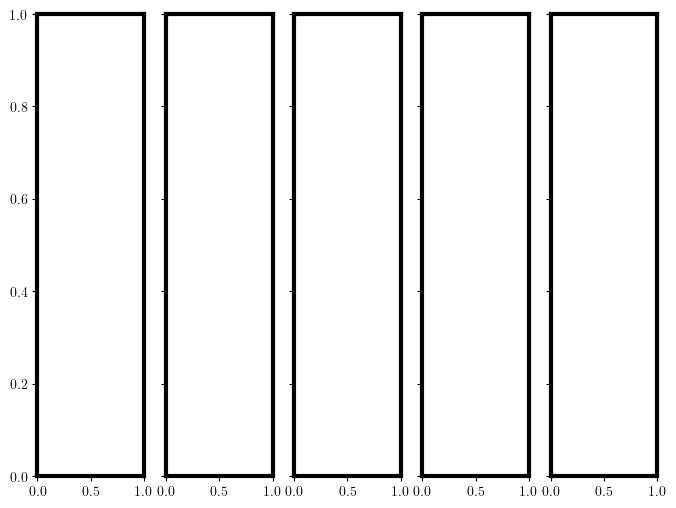

In [10]:
filename = f"QDDPMtotalloss_01_n{n}_na{na}_L{L}_T{T}.npy"
loss = np.load(savedir / filename)
fig, axs = plt.subplots(np.int(np.ceil(T/5)), 5, figsize=(8, 6), sharex=True, sharey=True)
for i in range(T):
    axs[i//5, i%5].plot(loss[i], lw=2)
    # axs[i//5, i%5].tick_params(direction='in', length=6, width=2, top='on', right='on', labelsize=20)
    axs[i//5, i%5].text(x=30, y=0.8, s=r'$t=%d$'%(i+1), fontsize=10)
    axs[i//5, i%5].set_yscale('log')
fig.supxlabel(r'$\rm iterations$', fontsize=30)
fig.supylabel(r'$\mathcal{L}(t)$', fontsize=30)
plt.tight_layout()